In [1]:
import pandas as pd

# 导入数据集
df = pd.read_csv('model.csv')

# 查看前5行
print(df.head())

# 查看数据维度
print("数据集形状：", df.shape)

# 查看所有列名
print("\n列名如下：")
print(df.columns.tolist())

   loanAmnt  term  interestRate  installment  grade  subGrade  homeOwnership  \
0   35000.0     5         19.52       917.97      4        21              2   
1   18000.0     5         18.49       461.90      3        16              0   
2   12000.0     5         16.99       298.17      3        17              0   
3   11000.0     3          7.26       340.96      0         3              1   
4    3000.0     3         12.99       101.07      2        11              1   

   verificationStatus  isDefault    dti  ...  ficoRangeHigh   title        n2  \
0                   2        1.0  17.05  ...          734.0     1.0  2.000000   
1                   2        0.0  27.83  ...          704.0  1723.0  5.646404   
2                   2        0.0  22.77  ...          679.0     0.0  3.000000   
3                   1        0.0  17.21  ...          689.0     4.0  6.000000   
4                   2        0.0  32.16  ...          694.0    11.0  7.000000   

         n3        n9       n14 

In [3]:
import pandas as pd

# 导入数据
df = pd.read_csv('model.csv')

# 需要转换的列
int_cols = [
    'loanAmnt',
    'n2',
    'n3',
    'n9',
    'n14',
    'isDefault'
]

# 转换为整数
for col in int_cols:
    df[col] = df[col].astype(int)

# 查看转换后的数据类型
print(df[int_cols].dtypes)

# 查看前5行
print(df.head())

# 查看数据集信息
df.info()

loanAmnt     int32
n2           int32
n3           int32
n9           int32
n14          int32
isDefault    int32
dtype: object
   loanAmnt  term  interestRate  installment  grade  subGrade  homeOwnership  \
0     35000     5         19.52       917.97      4        21              2   
1     18000     5         18.49       461.90      3        16              0   
2     12000     5         16.99       298.17      3        17              0   
3     11000     3          7.26       340.96      0         3              1   
4      3000     3         12.99       101.07      2        11              1   

   verificationStatus  isDefault    dti  ...  ficoRangeHigh   title  n2  n3  \
0                   2          1  17.05  ...          734.0     1.0   2   2   
1                   2          0  27.83  ...          704.0  1723.0   5   5   
2                   2          0  22.77  ...          679.0     0.0   3   3   
3                   1          0  17.21  ...          689.0     4.0   6   6

In [5]:
df.head()

,loanAmnt,term,interestRate,installment,grade,subGrade,homeOwnership,verificationStatus,isDefault,dti,...,ficoRangeHigh,title,n2,n3,n9,n14,annualIncome_log,revol_flag,issueDateDT,creditAge
0,35000,5,19.52,917.97,4,21,2,2,1,17.05,...,734.0,1.0,2,2,2,2,11.608245,1,2587,13
1,18000,5,18.49,461.90,3,16,0,2,0,27.83,...,704.0,1723.0,5,5,5,2,10.736418,1,1888,10
2,12000,5,16.99,298.17,3,17,0,2,0,22.77,...,679.0,0.0,3,3,3,4,11.211834,1,3044,9
3,11000,3,7.26,340.96,0,3,1,1,0,17.21,...,689.0,4.0,6,6,6,1,11.678448,1,2983,16
4,3000,3,12.99,101.07,2,11,1,2,0,32.16,...,694.0,11.0,7,7,7,4,10.275086,1,3196,39


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 读取数据
df = pd.read_csv('model.csv')

# 目标变量
target = 'isDefault'

# X 和 y
X = df.drop(target, axis=1)
y = df[target]

# 第一步：70%训练集，30%临时集
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 第二步：30%临时集再分成 20%验证集 + 10%测试集
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=1/3,
    random_state=42,
    stratify=y_temp
)

# 查看数据集大小
print("原始数据集:", df.shape)
print("训练集 X_train:", X_train.shape, "y_train:", y_train.shape)
print("验证集 X_val:", X_val.shape, "y_val:", y_val.shape)
print("测试集 X_test:", X_test.shape, "y_test:", y_test.shape)

# 查看违约率是否保持一致
print("\n违约率对比：")
print(f"原始数据集违约率: {y.mean():.6f}")
print(f"训练集违约率: {y_train.mean():.6f}")
print(f"验证集违约率: {y_val.mean():.6f}")
print(f"测试集违约率: {y_test.mean():.6f}")

# 查看各集合中 0/1 数量
print("\n原始数据集 isDefault 分布：")
print(y.value_counts())

print("\n训练集 isDefault 分布：")
print(y_train.value_counts())

print("\n验证集 isDefault 分布：")
print(y_val.value_counts())

print("\n测试集 isDefault 分布：")
print(y_test.value_counts())

原始数据集: (511886, 21)
训练集 X_train: (358320, 20) y_train: (358320,)
验证集 X_val: (102377, 20) y_val: (102377,)
测试集 X_test: (51189, 20) y_test: (51189,)

违约率对比：
原始数据集违约率: 0.195964
训练集违约率: 0.195965
验证集违约率: 0.195962
测试集违约率: 0.195960

原始数据集 isDefault 分布：
isDefault
0.0    411575
1.0    100311
Name: count, dtype: int64

训练集 isDefault 分布：
isDefault
0.0    288102
1.0     70218
Name: count, dtype: int64

验证集 isDefault 分布：
isDefault
0.0    82315
1.0    20062
Name: count, dtype: int64

测试集 isDefault 分布：
isDefault
0.0    41158
1.0    10031
Name: count, dtype: int64


Random Forest 验证集 AUC: 0.718565
XGBoost 验证集 AUC: 0.726064


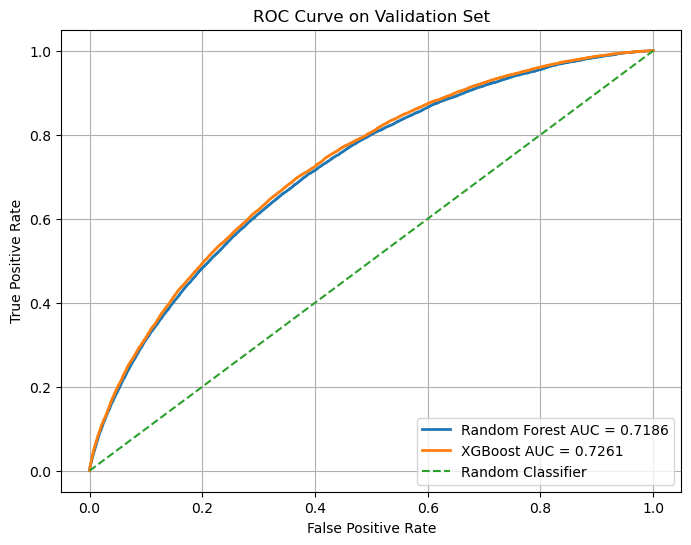

In [9]:
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from xgboost import XGBClassifier

# =========================
# 1. 创建并训练随机森林模型
# =========================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_val_proba = rf_model.predict_proba(X_val)[:, 1]
rf_auc = roc_auc_score(y_val, rf_val_proba)

print(f"Random Forest 验证集 AUC: {rf_auc:.6f}")


# =========================
# 2. 创建并训练 XGBoost 模型
# =========================

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_val_proba = xgb_model.predict_proba(X_val)[:, 1]
xgb_auc = roc_auc_score(y_val, xgb_val_proba)

print(f"XGBoost 验证集 AUC: {xgb_auc:.6f}")


# =========================
# 3. 画两个模型的 ROC 曲线
# =========================

rf_fpr, rf_tpr, _ = roc_curve(y_val, rf_val_proba)
xgb_fpr, xgb_tpr, _ = roc_curve(y_val, xgb_val_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=2,
    label=f'Random Forest AUC = {rf_auc:.4f}'
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    linewidth=2,
    label=f'XGBoost AUC = {xgb_auc:.4f}'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Validation Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

========== Random Forest 调参结果 ==========
{'n_estimators': 200, 'max_depth': 8, 'min_samples_leaf': 10} 验证集 AUC = 0.715671
{'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 10} 验证集 AUC = 0.718904
{'n_estimators': 300, 'max_depth': 10, 'min_samples_leaf': 10} 验证集 AUC = 0.718799
{'n_estimators': 300, 'max_depth': 12, 'min_samples_leaf': 5} 验证集 AUC = 0.720251

随机森林最优参数： {'n_estimators': 300, 'max_depth': 12, 'min_samples_leaf': 5}
随机森林最佳验证集 AUC： 0.720251

========== XGBoost 调参结果 ==========
{'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05} 验证集 AUC = 0.725295
{'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05} 验证集 AUC = 0.726074
{'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.03} 验证集 AUC = 0.72481
{'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.03} 验证集 AUC = 0.725606

XGBoost最优参数： {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05}
XGBoost最佳验证集 AUC： 0.726074

最终选择模型： XGBoost
最优参数： {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0

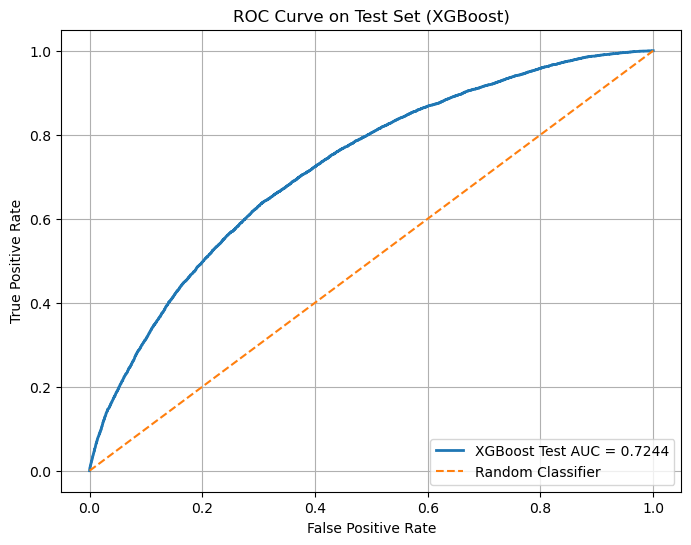

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from xgboost import XGBClassifier

# =========================
# 1. 随机森林参数微调
# =========================

rf_params_list = [
    {'n_estimators': 200, 'max_depth': 8,  'min_samples_leaf': 10},
    {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 10},
    {'n_estimators': 300, 'max_depth': 10, 'min_samples_leaf': 10},
    {'n_estimators': 300, 'max_depth': 12, 'min_samples_leaf': 5},
]

best_rf_auc = 0
best_rf_model = None
best_rf_params = None

print("========== Random Forest 调参结果 ==========")

for params in rf_params_list:
    rf_model = RandomForestClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_samples_leaf=params['min_samples_leaf'],
        random_state=42,
        n_jobs=-1
    )
    
    rf_model.fit(X_train, y_train)
    rf_val_proba = rf_model.predict_proba(X_val)[:, 1]
    rf_auc = roc_auc_score(y_val, rf_val_proba)
    
    print(params, "验证集 AUC =", round(rf_auc, 6))
    
    if rf_auc > best_rf_auc:
        best_rf_auc = rf_auc
        best_rf_model = rf_model
        best_rf_params = params

print("\n随机森林最优参数：", best_rf_params)
print("随机森林最佳验证集 AUC：", round(best_rf_auc, 6))


# =========================
# 2. XGBoost 参数微调
# =========================

xgb_params_list = [
    {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05},
    {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05},
    {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.03},
    {'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.03},
]

best_xgb_auc = 0
best_xgb_model = None
best_xgb_params = None

print("\n========== XGBoost 调参结果 ==========")

for params in xgb_params_list:
    xgb_model = XGBClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='auc',
        random_state=42,
        n_jobs=-1
    )
    
    xgb_model.fit(X_train, y_train)
    xgb_val_proba = xgb_model.predict_proba(X_val)[:, 1]
    xgb_auc = roc_auc_score(y_val, xgb_val_proba)
    
    print(params, "验证集 AUC =", round(xgb_auc, 6))
    
    if xgb_auc > best_xgb_auc:
        best_xgb_auc = xgb_auc
        best_xgb_model = xgb_model
        best_xgb_params = params

print("\nXGBoost最优参数：", best_xgb_params)
print("XGBoost最佳验证集 AUC：", round(best_xgb_auc, 6))


# =========================
# 3. 选择验证集 AUC 最好的模型
# =========================

if best_xgb_auc >= best_rf_auc:
    best_model = best_xgb_model
    best_model_name = "XGBoost"
    best_val_auc = best_xgb_auc
    best_params = best_xgb_params
else:
    best_model = best_rf_model
    best_model_name = "Random Forest"
    best_val_auc = best_rf_auc
    best_params = best_rf_params

print("\n================================")
print("最终选择模型：", best_model_name)
print("最优参数：", best_params)
print("最佳验证集 AUC：", round(best_val_auc, 6))
print("================================")


# =========================
# 4. 最优模型带入测试集
# =========================

y_test_proba = best_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_test_proba)

print("\n================================")
print(f"{best_model_name} 测试集 AUC = {test_auc:.6f}")
print("================================")


# =========================
# 5. 绘制测试集 ROC 曲线
# =========================

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'{best_model_name} Test AUC = {test_auc:.4f}'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve on Test Set ({best_model_name})')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Random Forest 测试集 AUC = 0.717141
XGBoost 测试集 AUC = 0.724361


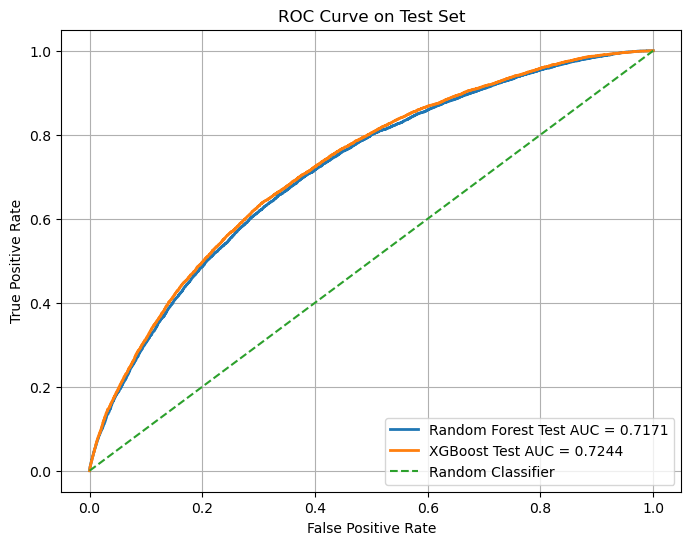

In [13]:
# =========================
# 4. 两个最优模型都带入测试集
# =========================

rf_test_proba = best_rf_model.predict_proba(X_test)[:, 1]
xgb_test_proba = best_xgb_model.predict_proba(X_test)[:, 1]

rf_test_auc = roc_auc_score(y_test, rf_test_proba)
xgb_test_auc = roc_auc_score(y_test, xgb_test_proba)

print(f"Random Forest 测试集 AUC = {rf_test_auc:.6f}")
print(f"XGBoost 测试集 AUC = {xgb_test_auc:.6f}")


# =========================
# 5. 同一张图画两个模型的测试集 ROC 曲线
# =========================

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_test_proba)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_test_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=2,
    label=f'Random Forest Test AUC = {rf_test_auc:.4f}'
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    linewidth=2,
    label=f'XGBoost Test AUC = {xgb_test_auc:.4f}'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()